# 05 — Train MobileNetV3 Breeding-Site Classifier (Binary)
**DengueSense LK — Final Year Project**

In [21]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

ROOT = "data/processed/cnn_breeding_site"   
IMG_SIZE = (224, 224)   # MobileNetV3 standard input
BATCH_SIZE = 32
EPOCHS = 10
SEED = 42
random.seed(SEED)

## Build a positive/negative manifest (image path + label)

In [22]:
import yaml

def read_data_yaml(root):
    yaml_path = os.path.join(root, "data.yaml")
    if not os.path.isfile(yaml_path):
        print(f"[!] No data.yaml found in {root}")
        return None
    with open(yaml_path) as f:
        return yaml.safe_load(f).get("names")

def detect_splits(root):
    found = {}
    for name in os.listdir(root):
        split_dir = os.path.join(root, name)
        img_dir = os.path.join(split_dir, "images")
        lbl_dir = os.path.join(split_dir, "labels")
        if os.path.isdir(img_dir) and os.path.isdir(lbl_dir):
            found[name] = {"images": img_dir, "labels": lbl_dir}
    return found

CLASS_NAMES = read_data_yaml(ROOT)
splits = detect_splits(ROOT)
print("Classes found in merged dataset:", CLASS_NAMES)
print("Splits found:", list(splits.keys()))

if not CLASS_NAMES:
    CLASS_NAMES = ["Breeding Place", "Mosquito", "Mosquito Swarm",
                   "Bottle", "Coconut-Exocarp", "Drain-Inlet", "Tire", "Vase"]
    print("[!] Using fallback class list - VERIFY this matches your label file class IDs:")
    print("   ", CLASS_NAMES)

Classes found in merged dataset: ['Breeding Place', 'Mosquito', 'Mosquito Swarm', 'Bottle', 'Coconut-Exocarp', 'Drain-Inlet', 'Tire', 'Vase']
Splits found: ['test', 'train', 'valid']


In [23]:
POSITIVE_KEYWORDS = ["breed", "bottle", "coconut", "drain", "tire", "vase", "mosquito"]
positive_ids = {i for i, n in enumerate(CLASS_NAMES)
                 if any(k in n.lower() for k in POSITIVE_KEYWORDS)}
negative_ids = {i for i in range(len(CLASS_NAMES))} - positive_ids
print("Positive (breeding-site) class ids:", positive_ids, "->", [CLASS_NAMES[i] for i in positive_ids])
print("Negative (no breeding-site) class ids:", negative_ids, "->", [CLASS_NAMES[i] for i in negative_ids])

def label_image(lbl_path):
    """1 if the image has any breeding-site object, 0 if it only has other objects or none at all."""
    lines = open(lbl_path).read().splitlines()
    class_ids = {int(float(l.split()[0])) for l in lines if l.strip()}
    if class_ids & positive_ids:
        return 1
    return 0   # covers: only negative-class objects, OR a completely empty label file

all_rows = []
for split, dirs in splits.items():
    for lbl_file in os.listdir(dirs["labels"]):
        stem = lbl_file.rsplit(".", 1)[0]
        label = label_image(os.path.join(dirs["labels"], lbl_file))
        for ext in [".jpg", ".jpeg", ".png"]:
            img_path = os.path.join(dirs["images"], stem + ext)
            if os.path.isfile(img_path):
                all_rows.append({"split": split, "path": img_path, "label": label})
                break

all_df = pd.DataFrame(all_rows)
print("\nTotal images labeled:", len(all_df))
print(all_df.groupby("split")["label"].value_counts())

Positive (breeding-site) class ids: {0, 1, 2, 3, 4, 5, 6, 7} -> ['Breeding Place', 'Mosquito', 'Mosquito Swarm', 'Bottle', 'Coconut-Exocarp', 'Drain-Inlet', 'Tire', 'Vase']
Negative (no breeding-site) class ids: set() -> []

Total images labeled: 17397
split  label
test   0         686
       1         233
train  1        9503
       0        5820
valid  0         685
       1         470
Name: count, dtype: int64


In [24]:
from sklearn.utils.class_weight import compute_class_weight

MAX_RATIO = 1 
manifests = {}
for split in ["train", "valid", "test"]:
    split_df = all_df[all_df["split"] == split]
    p = split_df[split_df["label"] == 1]
    n = split_df[split_df["label"] == 0]
    if len(n) == 0:
        print(f"[!] {split}: NO negative examples found - check the label/keyword mapping above")
        manifests[split] = split_df
        continue
    cap = min(len(p), len(n) * MAX_RATIO)
    combined = pd.concat([
        p.sample(n=cap, random_state=SEED) if cap < len(p) else p,
        n
    ]).sample(frac=1, random_state=SEED).reset_index(drop=True)
    manifests[split] = combined
    print(f"{split:6s} -> positives kept: {(combined['label']==1).sum():5d}  "
          f"negatives kept: {(combined['label']==0).sum():5d}  total: {len(combined)}  "
          f"(ratio {(combined['label']==1).sum()/max(1,(combined['label']==0).sum()):.1f}:1)")

train_df = manifests["train"]
val_df   = manifests["valid"]
test_df  = manifests["test"]

try:
    weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df["label"].values)
except Exception:
    counts = np.bincount(train_df["label"].astype(int), minlength=2)
    total = counts.sum()
    weights = np.array([(total / (2 * c)) if c > 0 else 1.0 for c in counts])
class_weight = {0: float(weights[0]), 1: float(weights[1])}
print("\nClass weights (used in model.fit):", class_weight)

train  -> positives kept:  5820  negatives kept:  5820  total: 11640  (ratio 1.0:1)
valid  -> positives kept:   470  negatives kept:   685  total: 1155  (ratio 0.7:1)
test   -> positives kept:   233  negatives kept:   686  total: 919  (ratio 0.3:1)

Class weights (used in model.fit): {0: 1.0, 1: 1.0}


In [25]:
print("Train:", len(train_df), "| Validation:", len(val_df), "| Test (held out):", len(test_df))
print("\nTrain label balance:\n", train_df['label'].value_counts())
print("\nValidation label balance:\n", val_df['label'].value_counts())
print("\nTest label balance:\n", test_df['label'].value_counts())

Train: 11640 | Validation: 1155 | Test (held out): 919

Train label balance:
 label
0    5820
1    5820
Name: count, dtype: int64

Validation label balance:
 label
0    685
1    470
Name: count, dtype: int64

Test label balance:
 label
0    686
1    233
Name: count, dtype: int64


## Build a tf.data pipeline (no flow_from_directory needed)

In [26]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(df, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["label"].values.astype("float32")))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.15),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.1, 0.1),
            layers.RandomBrightness(0.15),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True, augment=True)
val_ds   = make_dataset(val_df, shuffle=False, augment=False)
test_ds  = make_dataset(test_df, shuffle=False, augment=False)   # held out, only used in Section 7
print("Datasets ready.")

Datasets ready.


## Build the model (Transfer Learning)
Same MobileNetV3Large backbone as before, but now a single sigmoid output for
**breeding_site present (1) vs not (0)**, instead of a 3-way softmax.

In [27]:
base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet')

base_model.trainable = False   # freeze the pretrained backbone first

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')   # binary output: breeding_site probability
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           961 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,997,313 (11.43 MB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

## Train

In [28]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/15


g:\Miniconda3\envs\foml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


364/364 ━━━━━━━━━━━━━━━━━━━━ 248s 615ms/step - accuracy: 0.9060 - loss: 0.2576 - precision: 0.8982 - recall: 0.9158 - val_accuracy: 0.9818 - val_loss: 0.0702 - val_precision: 0.9610 - val_recall: 0.9957 - learning_rate: 0.0010
Epoch 2/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 194s 514ms/step - accuracy: 0.9383 - loss: 0.1874 - precision: 0.9285 - recall: 0.9498 - val_accuracy: 0.9931 - val_loss: 0.0470 - val_precision: 0.9873 - val_recall: 0.9957 - learning_rate: 0.0010
Epoch 3/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 179s 480ms/step - accuracy: 0.9441 - loss: 0.1678 - precision: 0.9336 - recall: 0.9562 - val_accuracy: 0.9931 - val_loss: 0.0402 - val_precision: 0.9853 - val_recall: 0.9979 - learning_rate: 0.0010
Epoch 4/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 192s 516ms/step - accuracy: 0.9448 - loss: 0.1624 - precision: 0.9354 - recall: 0.9557 - val_accuracy: 0.9922 - val_loss: 0.0434 - val_precision: 0.9832 - val_recall: 0.9979 - learning_rate: 0.0010
Epoch 5/15
364/364 ━━━━━━━━━━━━━━━━━━━━ 209s 560ms/step - a

## Accuracy / loss curves

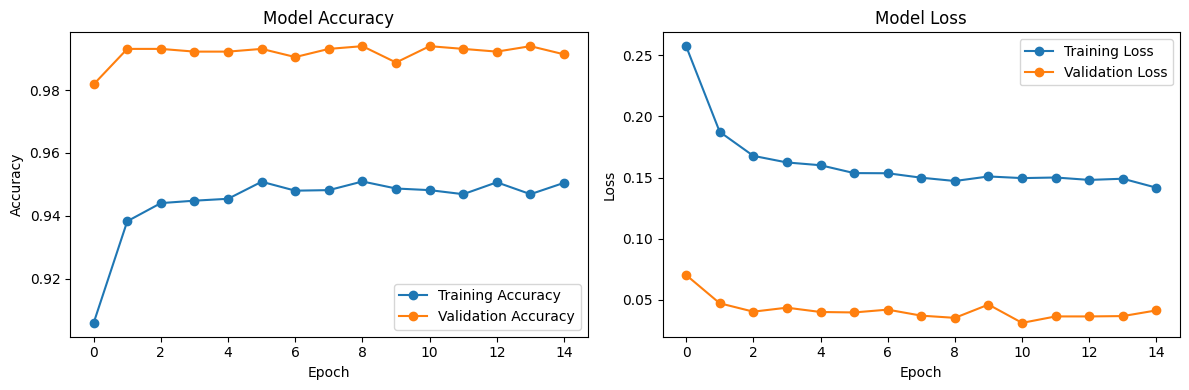

In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Evaluate — classification report + confusion matrix

29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 552ms/step
Classification Report (held-out TEST set):
                  precision    recall  f1-score   support

no_breeding_site       1.00      0.99      1.00       686
   breeding_site       0.97      1.00      0.99       233

        accuracy                           0.99       919
       macro avg       0.99      1.00      0.99       919
    weighted avg       0.99      0.99      0.99       919



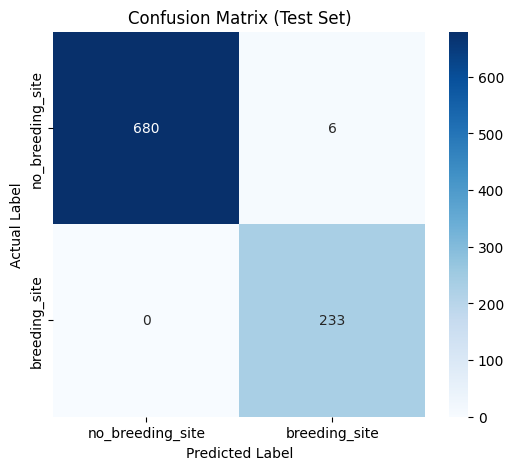

In [30]:
y_true = test_df["label"].values
y_pred_prob = model.predict(test_ds).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

class_names = ["no_breeding_site", "breeding_site"]

print("Classification Report (held-out TEST set):")
# Ensure report always has two rows (no_breeding_site, breeding_site)
labels = [0, 1]
print(classification_report(y_true, y_pred, labels=labels, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)'); plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Export the model

In [32]:
os.makedirs('models', exist_ok=True)

# Save for FastAPI Server (.keras)
model.save('models/mobilenetv3_breeding_site_classifier_v1.keras')
print("Model saved as models/mobilenetv3_breeding_site_classifier_v1.keras")

# Convert and save for Flutter App (.tflite)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('models/mobilenetv3_breeding_site_classifier_v1.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model saved as models/mobilenetv3_breeding_site_classifier_v1.tflite")

Model saved as models/mobilenetv3_breeding_site_classifier_v1.keras
INFO:tensorflow:Assets written to: C:\Users\Chathura\AppData\Local\Temp\tmpk52t24y8\assets


INFO:tensorflow:Assets written to: C:\Users\Chathura\AppData\Local\Temp\tmpk52t24y8\assets


Saved artifact at 'C:\Users\Chathura\AppData\Local\Temp\tmpk52t24y8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_637')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1508142514640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508141663056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508141663248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508141665744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508141666512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508141662672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508141664592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508133466384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508141662480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1508133467920: TensorSpec(shape=(), dtype=tf.resource, name=None)
